In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns

In [3]:
gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_combined_all_methods_detail.parquet")
gene_perf_GENEPERT = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_combined_GENEPERT_methods_detail.parquet")

with open("top_half_global_specificity.json") as f:
    top_genes = json.load(f)
with open("bottom_half_global_specificity.json") as f:
    bottom_genes = json.load(f)
    
mid = len(top_genes) // 2
top_quarter = top_genes[:mid]        # top 25% (71 genes)
second_quarter = top_genes[mid:]     # 25-50% (71 genes)

mid = len(bottom_genes) // 2
third_quarter = bottom_genes[:mid]   # 50-75% (71 genes)
bottom_quarter = bottom_genes[mid:]  # bottom 25% (71 genes)

In [4]:
gene_perf = pd.concat([gene_perf[gene_perf['method'] != 'GenePert'], gene_perf_GENEPERT], ignore_index=True)


In [5]:
new_metrics = compute_new_corr_metrics(
    gene_perf,
    deg=[1000, 2000, 5000],
    sign_tau=0.0,
    updown_tau=0.0,
    de_frac=0.1,
    topk_values=(100,),
    
)

Computed from gene_perf (DEG levels=[1000, 2000, 5000])
  include_metrics=['ccc_delta', 'cosine_distance_delta', 'de_auprc_distance_delta', 'de_auroc_distance_delta', 'mean_absolute_error_delta', 'pearson_distance_delta', 'pearson_distance_raw', 'sign_error_delta', 'spearman_distance_delta', 'spearman_distance_raw', 'topk_jaccard_distance_delta_k100', 'topk_precision_distance_delta_k100', 'updown_f1_distance_delta']
  sign_tau=0.0, updown_tau=0.0, de_frac=0.1, topk_values=[100]
  pearson_distance_raw:    32887 entries  (skipped 35 due to zero std)
  spearman_distance_raw:   32887 entries  (skipped 35 due to zero std)
  pearson_distance_delta:  32922 entries  (skipped 0 due to zero std)
  spearman_distance_delta: 32922 entries  (skipped 0 due to zero std)
  mean_absolute_error_delta: 32922 entries
  cosine_distance_delta: 32922 entries
  sign_error_delta: 32922 entries  (skipped 0 due to empty |true_delta| > sign_tau mask)
  updown_f1_distance_delta: 32922 entries
  de_auroc_distance_de

In [6]:
new_metrics1 = new_metrics[~(new_metrics.metric.str.contains('raw')) & ~(new_metrics.metric.isin(["mean_absolute_error_delta", "cosine_distance_delta", "ccc_delta"]))]
# (new_metrics.method != "GenePert") & 

In [7]:
METHOD_ORDER = ['trainMean', 'GenePert','scouter', 'scGPT', 'GEARS', 'CPA']

PALETTE = {
    'trainMean': '#386cb0',
    'GenePert': '#f0027f',
    'scouter': '#7fc97f',
    'scGPT': '#beaed4',
    'GEARS': '#fdc086',
    'CPA': '#ffff99',
    
}

SHORT_NAMES = {
    'pearson_distance_delta':       'Pearson',
    'spearman_distance_delta':      'Spearman',
    'cosine_distance_delta':        'Cosine',
    'mean_absolute_error_delta':    'MAE',
    'sign_error_delta':             'Sign Error',
    'updown_f1_distance_delta':     'Up/Down F1',
    'de_auroc_distance_delta':      'DE AUROC',
    'de_auprc_distance_delta':      'DE AUPRC',
    'topk_jaccard_distance_delta_k100':  'Top-100 Jaccard',
    'topk_precision_distance_delta_k100': 'Top-100 Precision',
    'ccc_delta':                    'CCC',
}



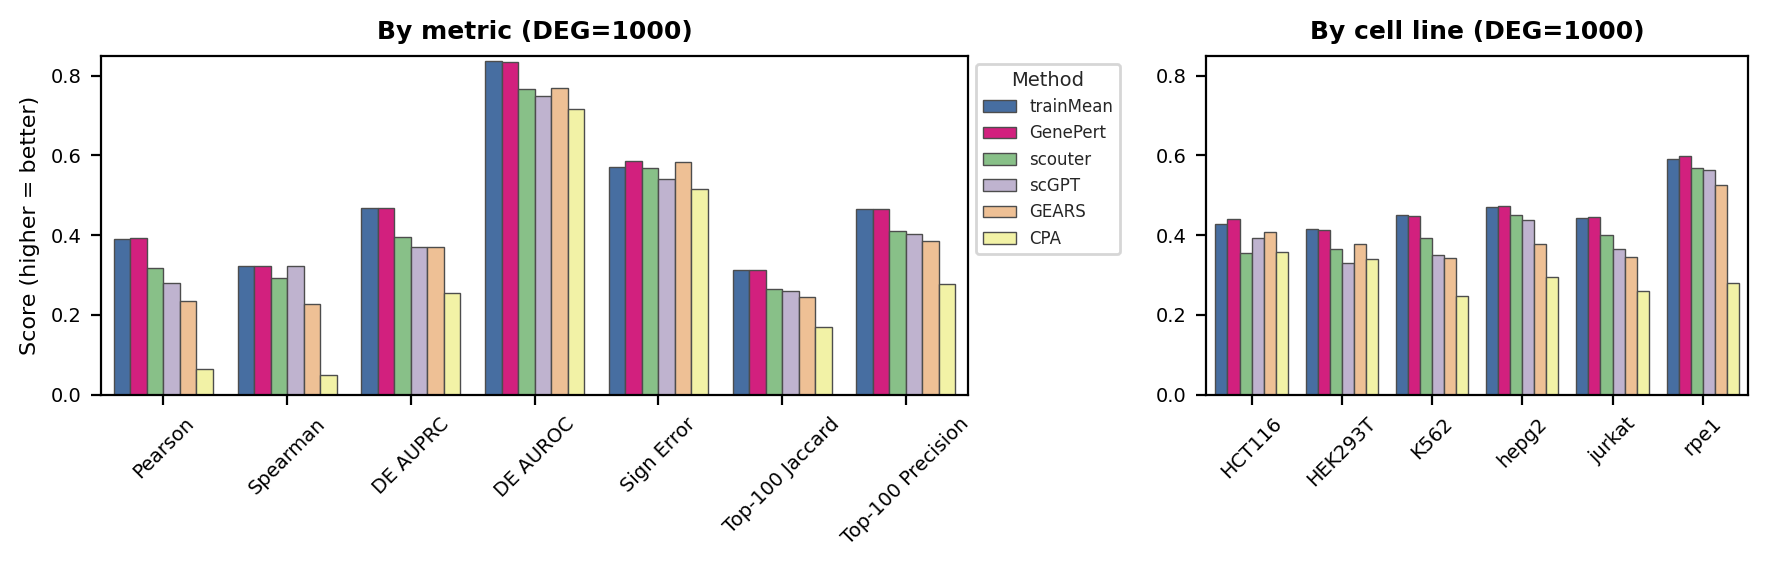

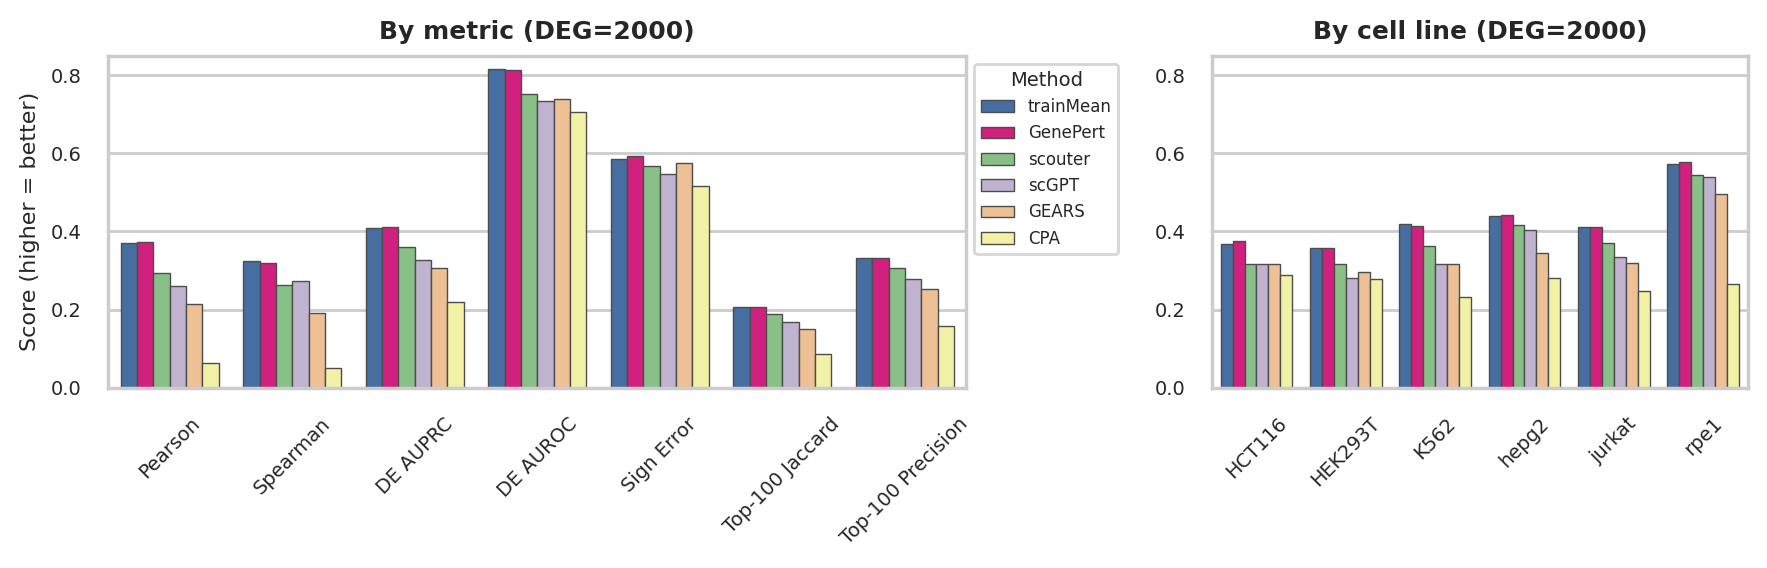

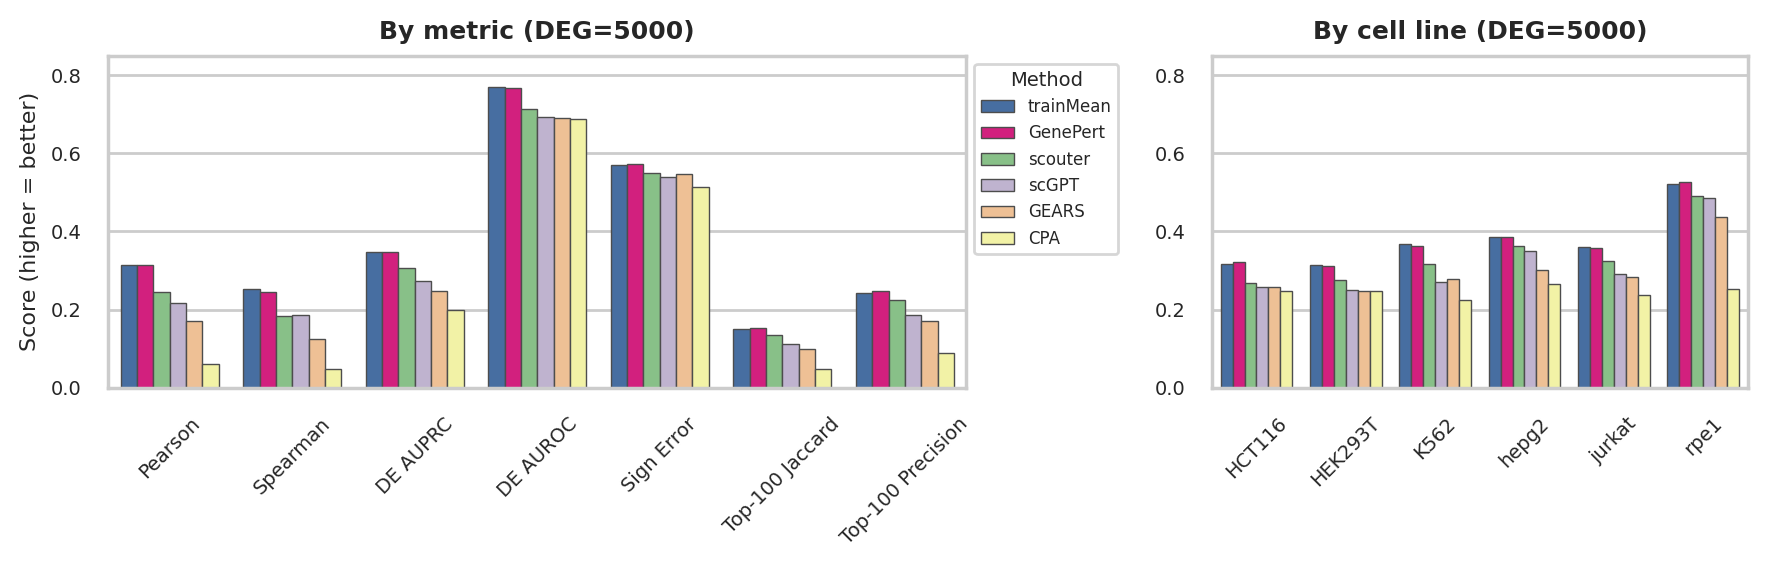

In [8]:
for deg in [1000, 2000, 5000]:
    results = method_performance_overview(
        new_metrics1[new_metrics1.DEG == deg],
        common_only=True,
        convert_higher_to_lower=True,
        verbose=False,
    )

    fig, axes = plt.subplots(1, 2, figsize=(9, 3), dpi=200, gridspec_kw={'width_ratios': [1.6, 1]})
    sns.set_theme(style="whitegrid")

    # Panel A: Method x Metric
    mm = results['method_metric'].loc[METHOD_ORDER].rename(columns=SHORT_NAMES)
    mm = 1 - mm
    mm = mm.drop(columns='Up/Down F1', errors='ignore')
    metric_order = ['Pearson', 'Spearman'] + sorted([c for c in mm.columns if c not in ['Pearson', 'Spearman']])
    mm = mm[metric_order]

    mm_long = mm.reset_index().melt(id_vars='method', var_name='Metric', value_name='Score')
    mm_long['Metric'] = pd.Categorical(mm_long['Metric'], categories=metric_order, ordered=True)
    sns.barplot(data=mm_long, x='Metric', y='Score', hue='method',
                hue_order=METHOD_ORDER, palette=PALETTE, ax=axes[0],
                edgecolor='0.3', linewidth=0.5)
    axes[0].set_ylim(0, 0.85)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Score (higher = better)', fontsize=8)
    axes[0].set_title(f'By metric (DEG={deg})', fontsize=9, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45, labelsize=7)
    axes[0].tick_params(axis='y', labelsize=7)
    axes[0].legend(fontsize=6, title_fontsize=7, title='Method', ncol=1,
                   bbox_to_anchor=(1.0, 1.0), loc='upper left')

    # Panel B: Method x Cell Line
    mc = results['method_cellline'].loc[METHOD_ORDER].drop(columns='mean')
    mc = 1 - mc
    mc_long = mc.reset_index().melt(id_vars='method', var_name='Cell line', value_name='Score')
    sns.barplot(data=mc_long, x='Cell line', y='Score', hue='method',
                hue_order=METHOD_ORDER, palette=PALETTE, ax=axes[1],
                edgecolor='0.3', linewidth=0.5)
    axes[1].set_ylim(0, 0.85)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')
    axes[1].set_title(f'By cell line (DEG={deg})', fontsize=9, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=7)
    axes[1].tick_params(axis='y', labelsize=7)
    axes[1].get_legend().remove()

    plt.tight_layout()
    plt.savefig(f'plots/plot2_grouped_bars_DEG{deg}.pdf', bbox_inches='tight', dpi=300)
    plt.show()


In [16]:
gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= 5000)].copy()

gene_avg = (gp_tm
    .groupby(['dataset', 'gene'])['mean_true_delta']
    .mean()
    .rename('avg_gene_delta')
)

gp_tm = gp_tm.merge(gene_avg, on=['dataset', 'gene'])
gp_tm['residual'] = gp_tm['mean_true_delta'] - gp_tm['avg_gene_delta']

psi = (gp_tm
    .groupby(['dataset', 'perturbation'])
    .apply(lambda g: g['residual'].var() / g['mean_true_delta'].var() if g['mean_true_delta'].var() > 0 else np.nan,
           include_groups=False)
    .rename('PSI')
    .reset_index()
)



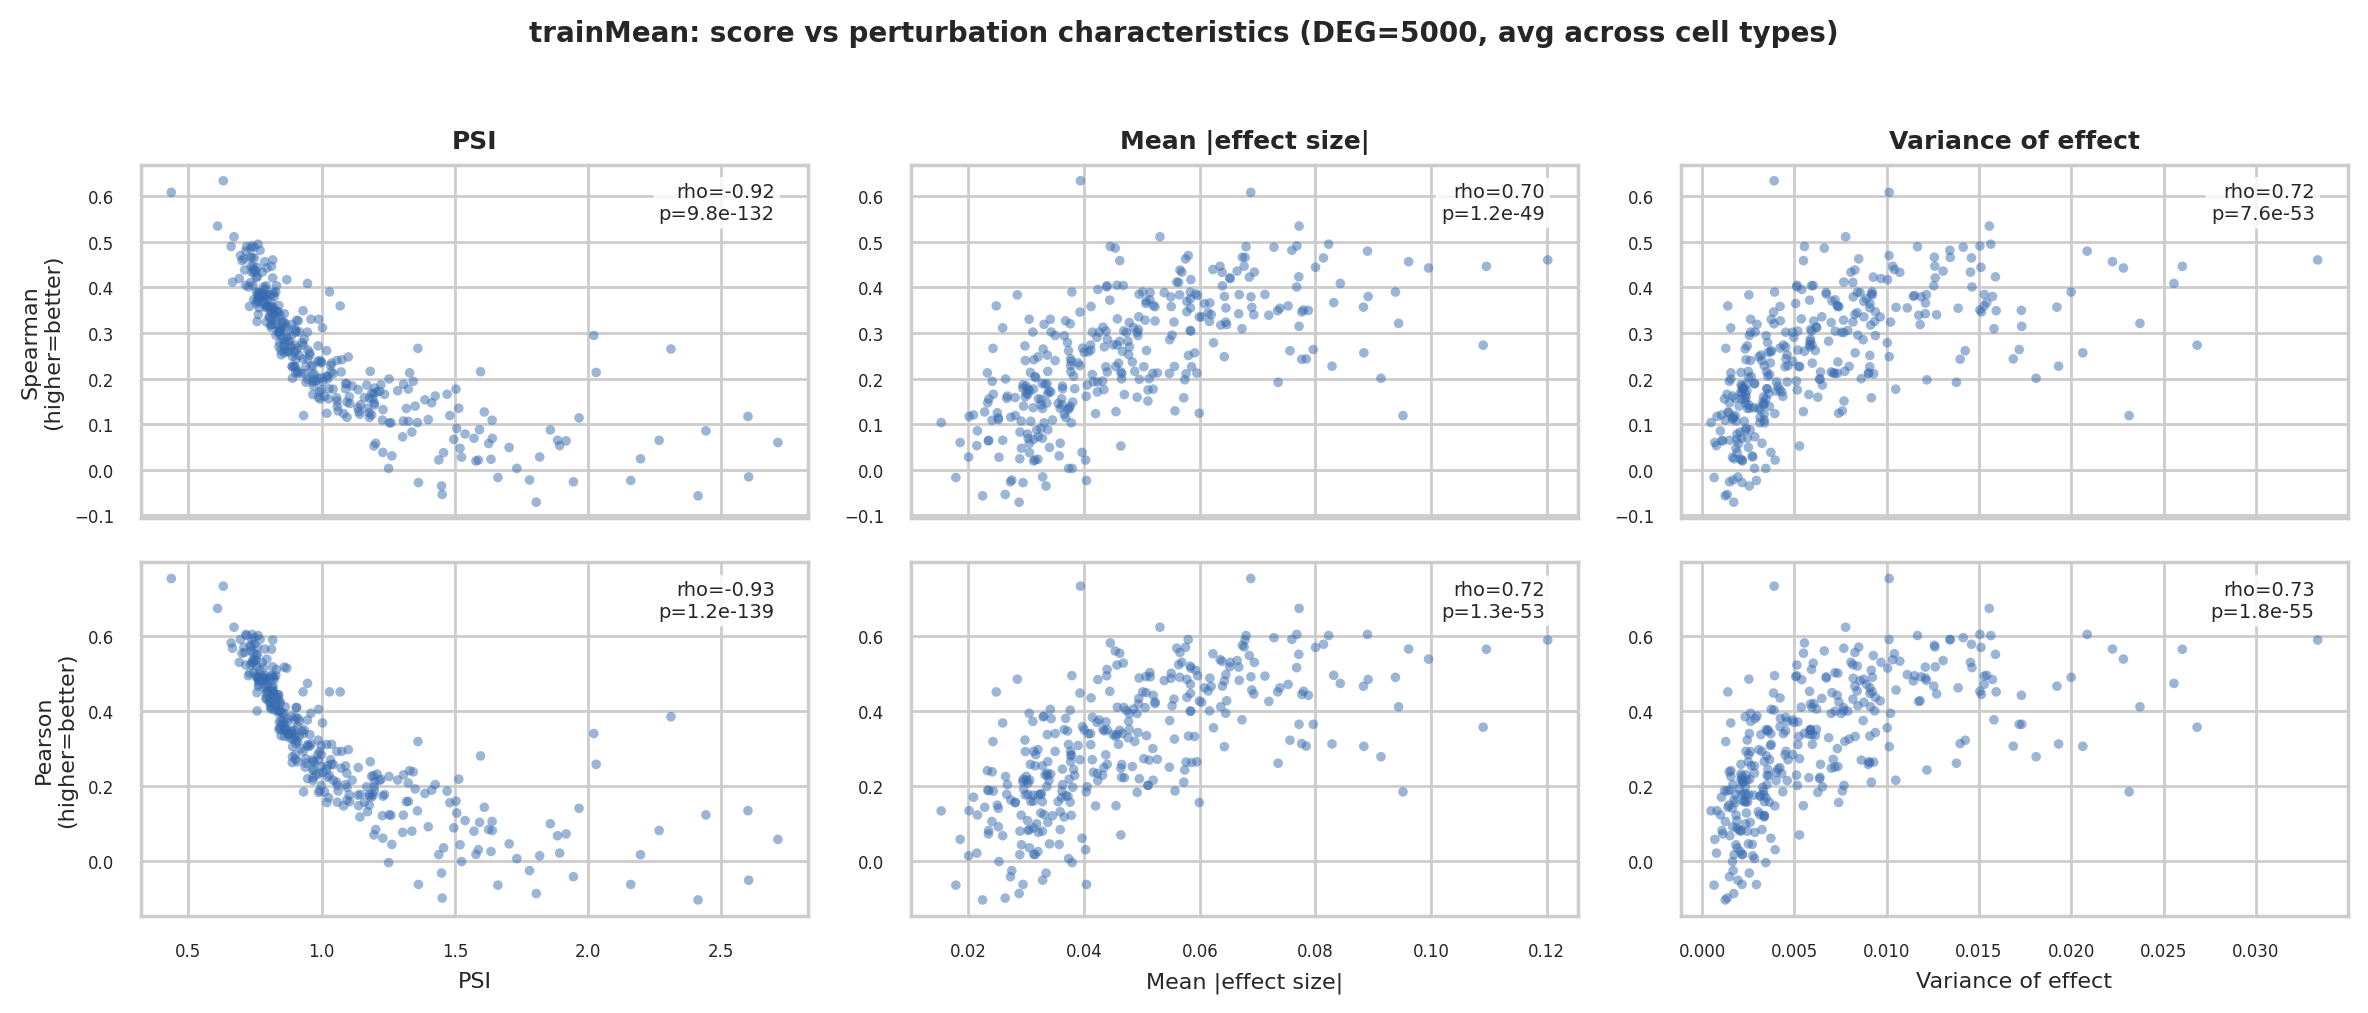

In [33]:
deg = 5000
gp = gene_perf[(gene_perf['deg_rank'] <= deg) & (gene_perf['method'] == 'trainMean')].copy()

pert_stats = (gp.groupby(['dataset', 'perturbation'])['mean_true_delta']
              .agg(mean_abs_effect=lambda x: np.abs(x).mean(),
                   var_effect=lambda x: x.var())
              .reset_index())

metrics_to_plot = [
    ('spearman_distance_delta', 'Spearman'),
    ('pearson_distance_delta', 'Pearson')
]

x_vars = [
    ('PSI', 'PSI'),
    ('mean_abs_effect', 'Mean |effect size|'),
    ('var_effect', 'Variance of effect'),
]

fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(12, 2.5 * len(metrics_to_plot)), dpi=200,
                         sharex='col')
sns.set_theme(style='whitegrid')

for i, (metric_name, metric_label) in enumerate(metrics_to_plot):
    perf = new_metrics[
        (new_metrics.DEG == deg)
        & (new_metrics.metric == metric_name)
        & (new_metrics.method == 'trainMean')
    ].copy()
    perf = perf.rename(columns={'DataSet': 'dataset', 'perturb': 'perturbation'})

    merged = perf.merge(psi, on=['dataset', 'perturbation'], how='inner')
    merged = merged.merge(pert_stats, on=['dataset', 'perturbation'], how='inner')

    # Average across cell types, convert to higher=better
    avg = merged.groupby('perturbation').agg(
        performance=('performance', 'mean'),
        PSI=('PSI', 'mean'),
        mean_abs_effect=('mean_abs_effect', 'mean'),
        var_effect=('var_effect', 'mean'),
    ).reset_index()
    avg['score'] = 1 - avg['performance']

    for j, (xcol, xlabel) in enumerate(x_vars):
        ax = axes[i, j]
        ax.scatter(avg[xcol], avg['score'],
                   alpha=0.5, s=12, color=PALETTE['trainMean'], edgecolors='none')

        valid = avg[[xcol, 'score']].dropna()
        if len(valid) >= 3:
            rho, p = spearmanr(valid[xcol], valid['score'])
            ax.text(0.95, 0.95, f'rho={rho:.2f}\np={p:.1e}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

        if i == len(metrics_to_plot) - 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if j == 0:
            ax.set_ylabel(f'{metric_label}\n(higher=better)', fontsize=8)
        ax.tick_params(labelsize=6)

        if i == 0:
            ax.set_title(xlabel, fontsize=9, fontweight='bold')

plt.suptitle(f'trainMean: score vs perturbation characteristics (DEG={deg}, avg across cell types)',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'plots/plot_scatter_trainMean_multimetric_DEG{deg}.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [17]:
# Filter to DEG=5000
perf = new_metrics[new_metrics.DEG == 5000].copy()
perf = perf.rename(columns={'DataSet': 'dataset', 'perturb': 'perturbation'})

# Keep only perturbations present in all cell types
datasets = perf['dataset'].unique()
common_perts = (perf.groupby('perturbation')['dataset'].nunique()
                .loc[lambda x: x == len(datasets)].index)
perf = perf[perf['perturbation'].isin(common_perts)]
print(f"Common perturbations across {len(datasets)} cell types: {len(common_perts)}")

# Merge
merged = perf.merge(psi, on=['dataset', 'perturbation'], how='inner')

n_match = merged.groupby('dataset')['perturbation'].nunique()
print("Perturbations matched per dataset:")
print(n_match)
print(f"\nTotal unique perturbations matched: {merged['perturbation'].nunique()}")

# Spearman correlation of PSI vs performance, per method x metric
from scipy.stats import spearmanr

rows = []
for (method, metric), sub in merged.groupby(['method', 'metric']):
    avg = sub.groupby(['dataset', 'perturbation']).agg(
        performance=('performance', 'mean'),
        PSI=('PSI', 'first')
    ).dropna()
    
    if len(avg) >= 3:
        rho, p = spearmanr(avg['PSI'], avg['performance'])
    else:
        rho, p = np.nan, np.nan
    
    rows.append({'method': method, 'metric': metric, 'rho': rho, 'p': p, 'n': len(avg)})

corr_df = pd.DataFrame(rows)

rho_pivot = corr_df.pivot(index='method', columns='metric', values='rho')
print("\nSpearman rho (PSI vs performance):")
print(rho_pivot.round(4).to_string())


Common perturbations across 6 cell types: 284
Perturbations matched per dataset:
dataset
HCT116     284
HEK293T    284
K562       284
hepg2      284
jurkat     284
rpe1       284
Name: perturbation, dtype: int64

Total unique perturbations matched: 284

Spearman rho (PSI vs performance):
metric     ccc_delta  cosine_distance_delta  de_auprc_distance_delta  de_auroc_distance_delta  mean_absolute_error_delta  pearson_distance_delta  pearson_distance_raw  sign_error_delta  spearman_distance_delta  spearman_distance_raw  topk_jaccard_distance_delta_k100  topk_precision_distance_delta_k100  updown_f1_distance_delta
method                                                                                                                                                                                                                                                                                                                                  
CPA          -0.0958                 0.0810          

Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  284 shared perturbations across 6 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=0.058 (p=1.65e-02, n=1704)
           CPA vs GenePert    : rho=0.071 (p=3.46e-03, n=1704)
           CPA vs scGPT       : rho=0.106 (p=1.12e-05, n=1704)
           CPA vs scouter     : rho=0.090 (p=2.01e-04, n=1704)
           CPA vs trainMean   : rho=0.064 (p=8.19e-03, n=1704)
         GEARS vs GenePert    : rho=0.723 (p=3.02e-275, n=1704)
         GEARS vs scGPT       : rho=0.754 (p=1.89e-313, n=1704)
         GEARS vs scouter     : rho=0.662 (p=4.43e-215, n=1704)
         GEARS vs trainMean   : rho=0.736 (p=2.25e-290, n=1704)
      GenePert vs scGPT       : rho=0.865 (p=0.00e+00, n=1704)
      GenePert vs scouter     : rho=0.817 (p=0.00e+00, n=1704)
      GenePert vs trainMean   : rho=0.966 (p=0.00e+00, n=1704)
         scGPT vs scouter     : rho=0.731 (p=2.90e-284, n=

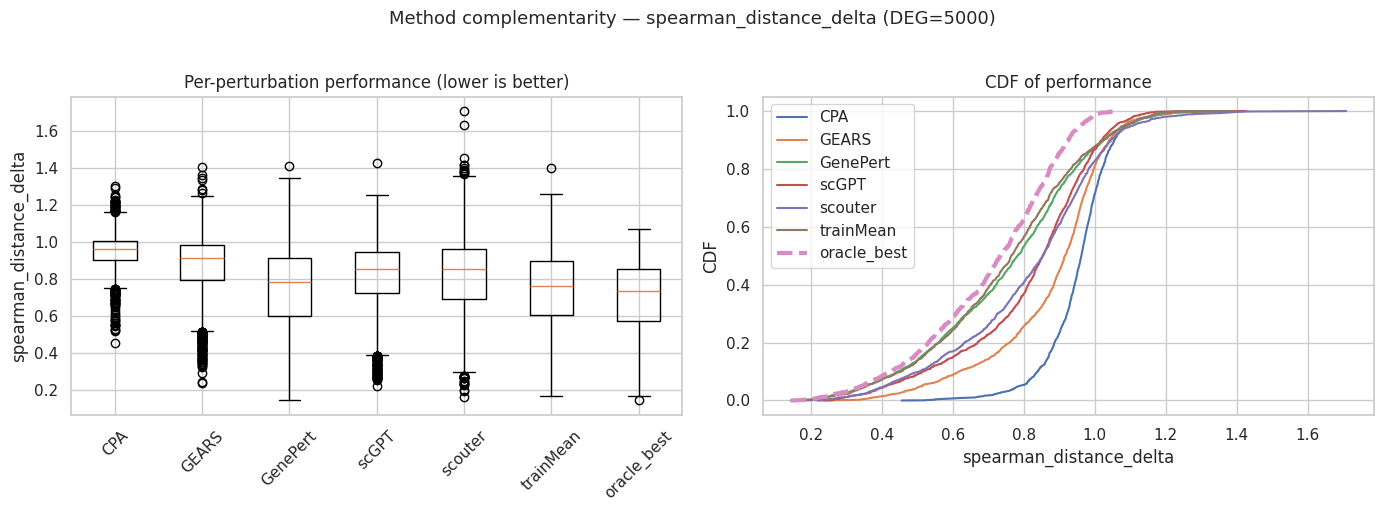

In [18]:

from results_modeling_helper import method_complementarity
pivot_all = method_complementarity(
    new_metrics, metric="spearman_distance_delta", deg=5000, baseline="trainMean"
)

/hpc/home/hl489/tmp/ipykernel_31192/3684335264.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=box_df, x='label', y='value', palette=palette_box, ax=axes[1],


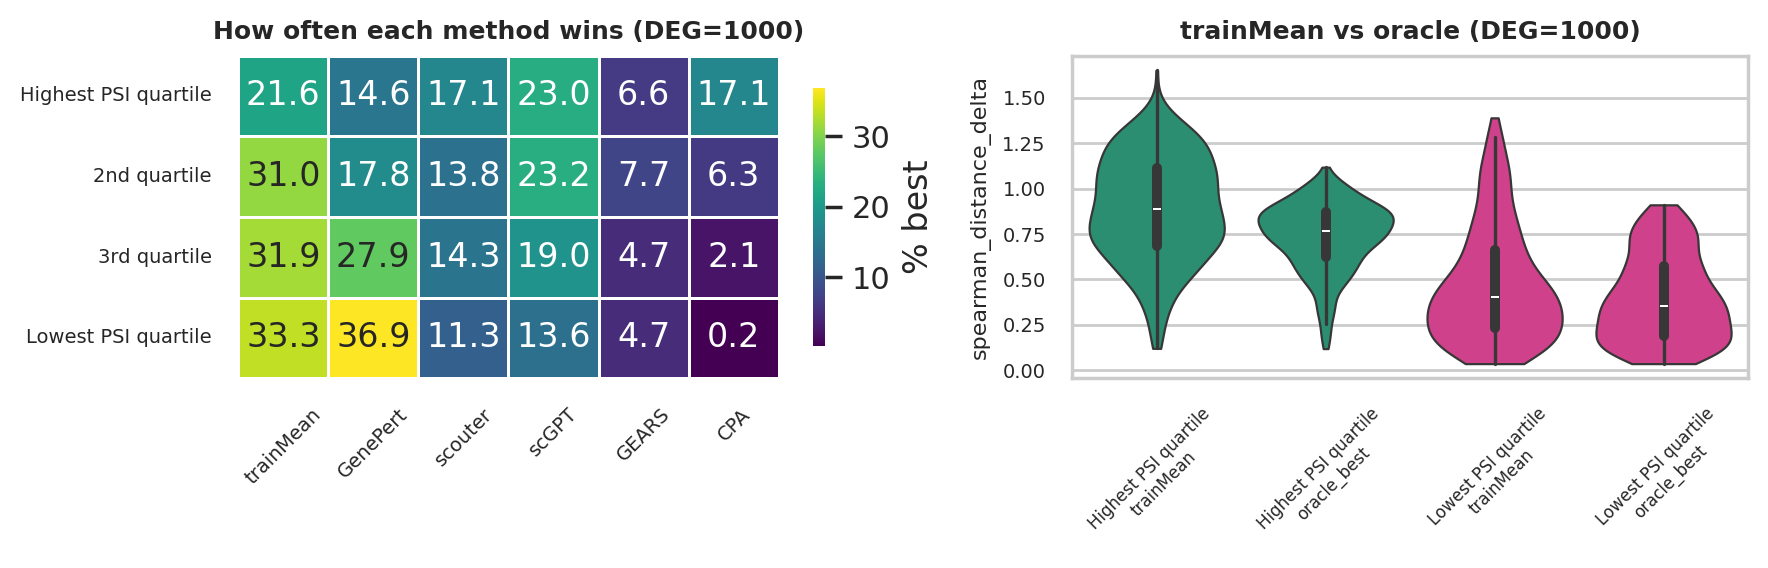

/hpc/home/hl489/tmp/ipykernel_31192/3684335264.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=box_df, x='label', y='value', palette=palette_box, ax=axes[1],


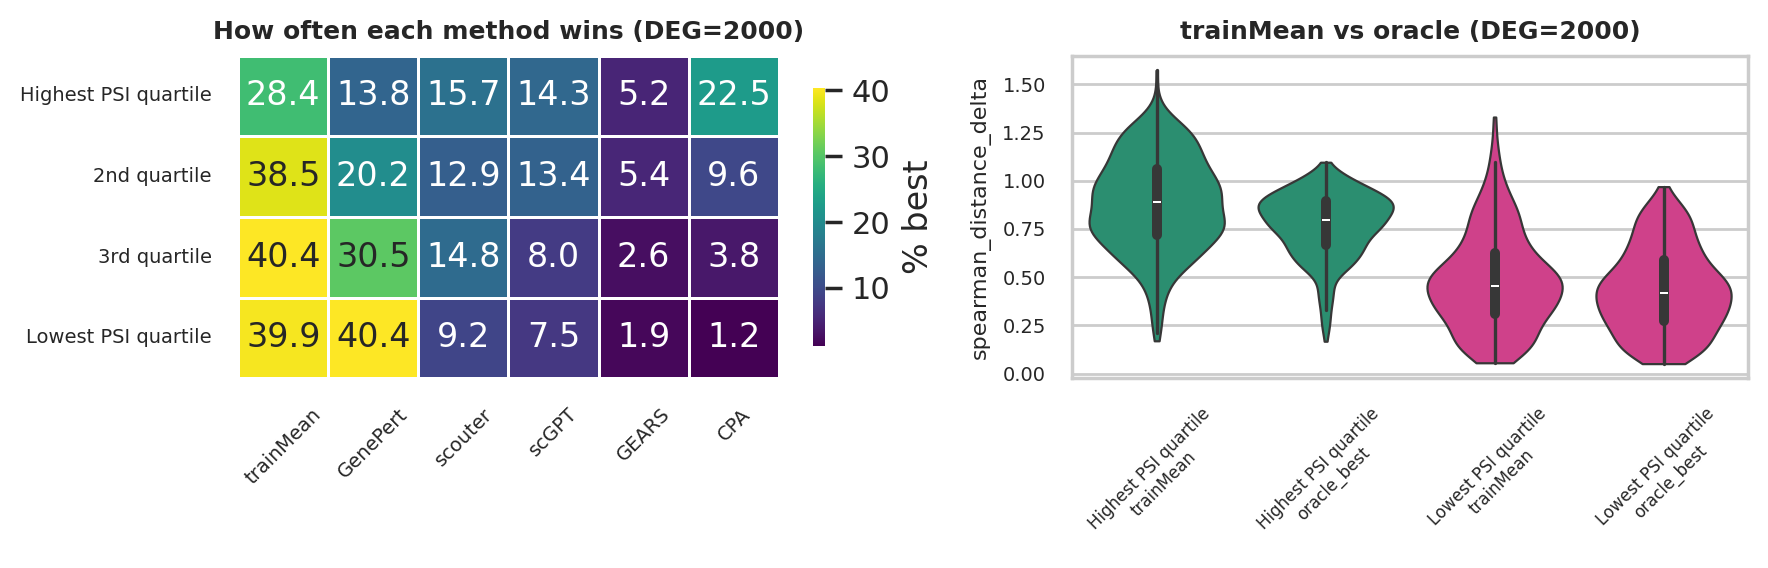

/hpc/home/hl489/tmp/ipykernel_31192/3684335264.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=box_df, x='label', y='value', palette=palette_box, ax=axes[1],


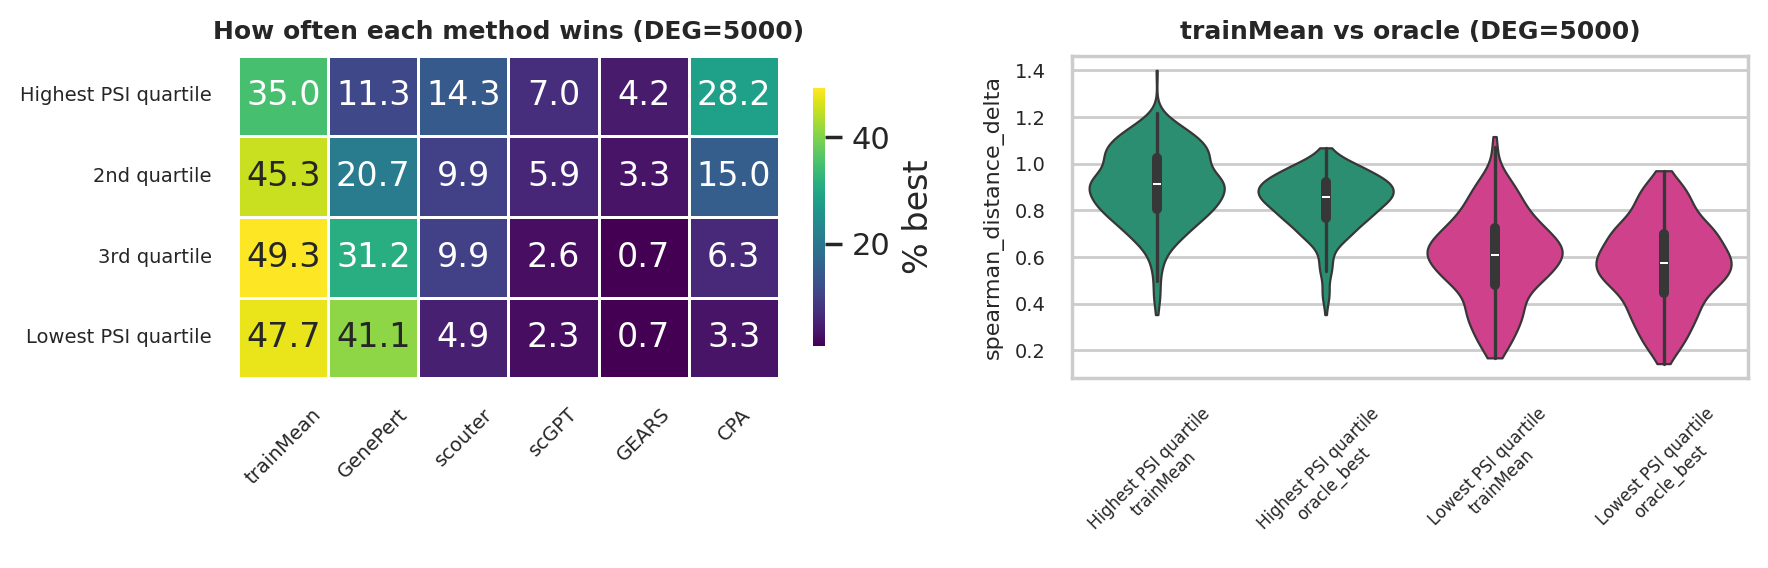

In [21]:
from scipy.stats import spearmanr
import itertools

quarter_names = ['Highest PSI quartile', '2nd quartile', '3rd quartile', 'Lowest PSI quartile']
quarter_lists = [top_quarter, second_quarter, third_quarter, bottom_quarter]

for deg in [1000, 2000, 5000]:
    best_counts_all = []
    cdf_data = {}

    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'spearman_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')
        methods = [m for m in METHOD_ORDER if m in pivot.columns]
        pivot = pivot[methods]

        pivot['oracle_best'] = pivot[methods].min(axis=1)
        pivot['best_method'] = pivot[methods].idxmin(axis=1)

        counts = pivot['best_method'].value_counts()
        for m in methods:
            best_counts_all.append({
                'quarter': qname, 'method': m,
                'pct': counts.get(m, 0) / len(pivot) * 100
            })

        if qname in ['Highest PSI quartile', 'Lowest PSI quartile']:
            for m in ['trainMean', 'oracle_best']:
                if m in pivot.columns:
                    vals = np.sort(pivot[m].dropna().values)
                    cdf_data[(qname, m)] = vals

    best_df = pd.DataFrame(best_counts_all)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3), dpi=200)
    sns.set_theme(style='whitegrid')

    # Panel A: Heatmap of % best
    best_pivot = best_df.pivot(index='quarter', columns='method', values='pct')
    best_pivot = best_pivot.reindex(quarter_names)
    best_pivot = best_pivot[[m for m in METHOD_ORDER if m in best_pivot.columns]]
    sns.heatmap(best_pivot, annot=True, fmt='.1f', cmap='viridis', ax=axes[0],
                linewidths=0.5, vmin=best_pivot.values.min(), vmax=best_pivot.values.max(),
                cbar_kws={'shrink': 0.8, 'label': '% best'})
    axes[0].set_ylabel('')
    axes[0].set_xlabel('')
    axes[0].set_title(f'How often each method wins (DEG={deg})', fontsize=9, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45, labelsize=7)
    axes[0].tick_params(axis='y', rotation=0, labelsize=7)

    # Panel B: Violin plots — highest and lowest PSI quartiles only
    box_data = []
    for qname in ['Highest PSI quartile', 'Lowest PSI quartile']:
        for m in ['trainMean', 'oracle_best']:
            if (qname, m) in cdf_data:
                for v in cdf_data[(qname, m)]:
                    box_data.append({'quarter': qname, 'source': m, 'value': v})
    box_df = pd.DataFrame(box_data)
    box_df['label'] = box_df['quarter'] + '\n' + box_df['source']

    colors_q = {'Highest PSI quartile': '#1b9e77', 'Lowest PSI quartile': '#e7298a'}
    palette_box = {}
    for _, row in box_df[['quarter', 'label']].drop_duplicates().iterrows():
        palette_box[row['label']] = colors_q[row['quarter']]

    sns.violinplot(data=box_df, x='label', y='value', palette=palette_box, ax=axes[1],
                   inner='box', linewidth=0.8, cut=0)
    axes[1].set_xlabel('', fontsize=8)
    axes[1].set_ylabel('spearman_distance_delta', fontsize=8)
    axes[1].set_title(f'trainMean vs oracle (DEG={deg})', fontsize=9, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=6)
    axes[1].tick_params(axis='y', labelsize=7)

    plt.tight_layout()
    plt.savefig(f'plots/plot_complementarity_quarters_DEG{deg}.pdf', bbox_inches='tight', dpi=300)
    plt.show()


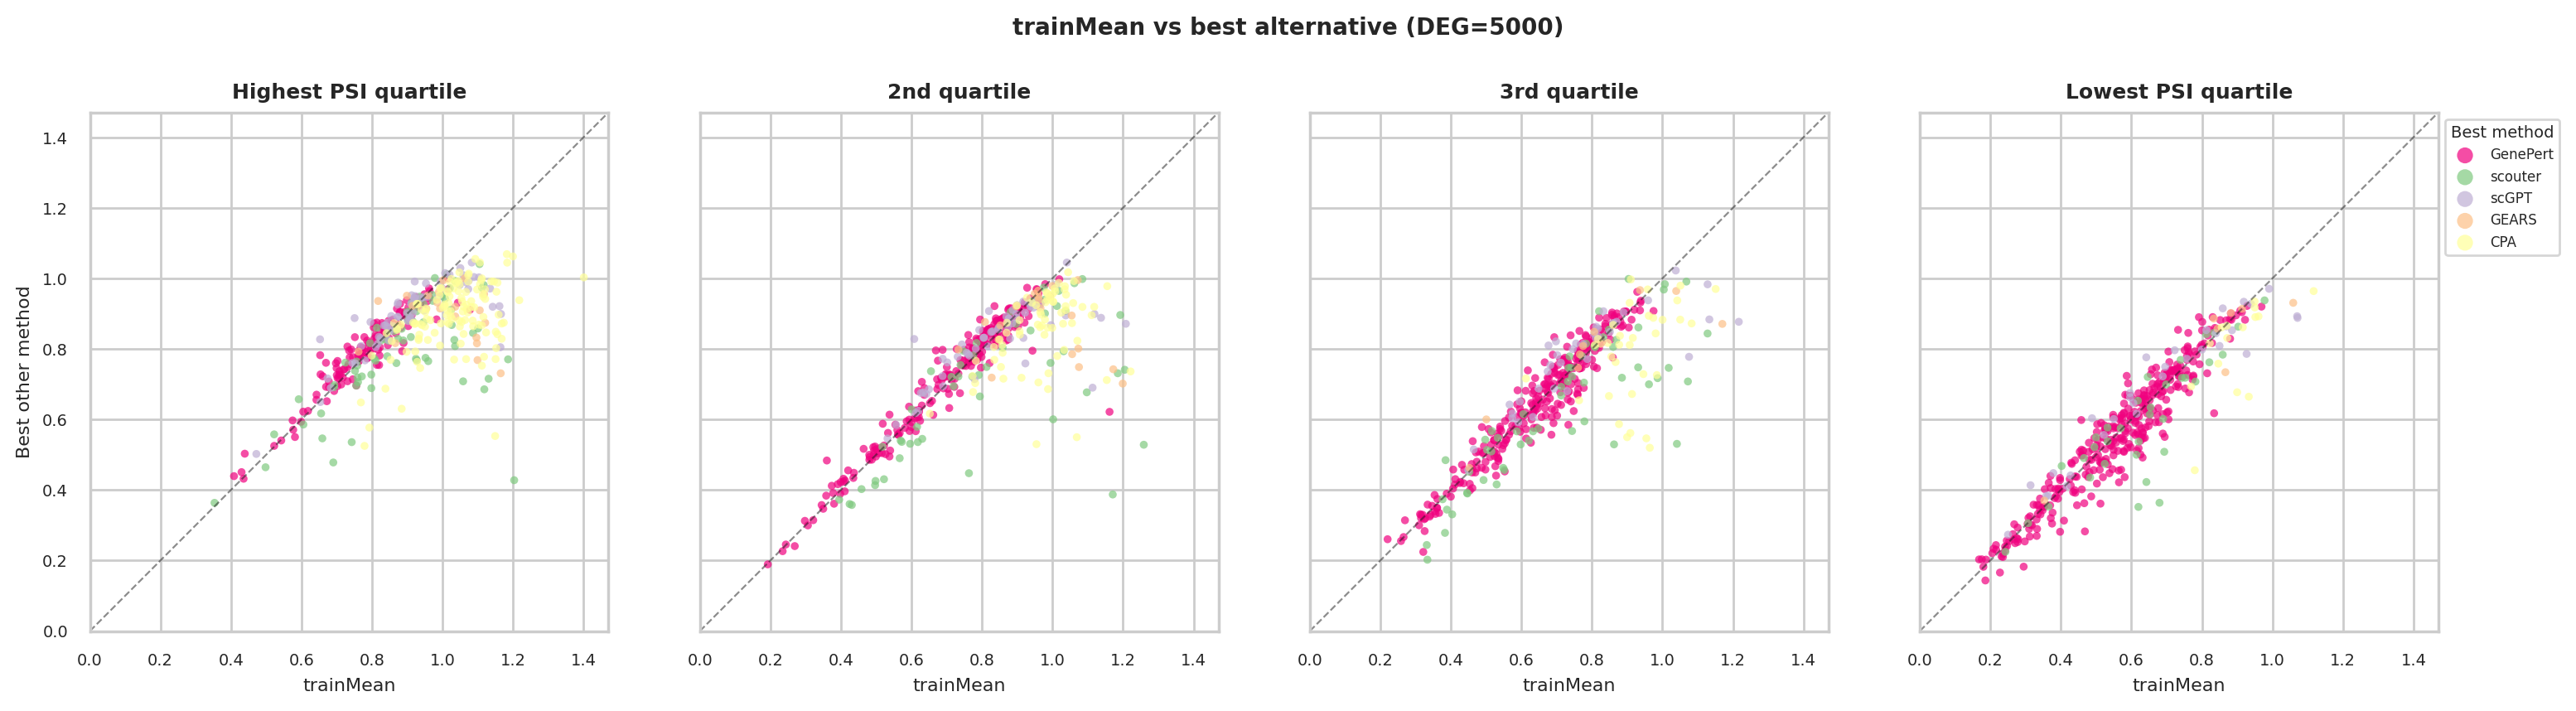

In [28]:
from scipy.stats import spearmanr
import itertools

quarter_names = ['Highest PSI quartile', '2nd quartile', '3rd quartile', 'Lowest PSI quartile']
quarter_lists = [top_quarter, second_quarter, third_quarter, bottom_quarter]
other_methods = [m for m in METHOD_ORDER if m != 'trainMean']

deg = 5000
scatter_data = []

for qname, qlist in zip(quarter_names, quarter_lists):
    sub = new_metrics[
        (new_metrics.metric == 'spearman_distance_delta')
        & (new_metrics.DEG == deg)
        & (new_metrics.perturb.isin(qlist))
    ].copy()

    all_ds = sub['DataSet'].unique()
    pcounts = sub.groupby('perturb')['DataSet'].nunique()
    shared = pcounts[pcounts == len(all_ds)].index
    sub = sub[sub['perturb'].isin(shared)]

    agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
    pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

    if 'trainMean' not in pivot.columns:
        continue

    om = [m for m in other_methods if m in pivot.columns]
    pivot['best_other'] = pivot[om].min(axis=1)
    pivot['best_other_method'] = pivot[om].idxmin(axis=1)

    for idx, row in pivot.iterrows():
        scatter_data.append({
            'quarter': qname,
            'trainMean': row['trainMean'],
            'best_other': row['best_other'],
            'best_method': row['best_other_method'],
        })

sc_df = pd.DataFrame(scatter_data)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=200, sharey=True, sharex=True)
sns.set_theme(style='whitegrid')

method_colors = {m: PALETTE[m] for m in other_methods}

for i, qname in enumerate(quarter_names):
    ax = axes[i]
    qsub = sc_df[sc_df.quarter == qname]

    for m in other_methods:
        msub = qsub[qsub.best_method == m]
        ax.scatter(msub['trainMean'], msub['best_other'],
                   alpha=0.7, s=12, color=method_colors[m], label=m, edgecolors='none')

    lims = [0, max(sc_df['trainMean'].max(), sc_df['best_other'].max()) * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('trainMean', fontsize=8)
    if i == 0:
        ax.set_ylabel('Best other method', fontsize=8)
    ax.set_title(qname, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')

    if i == 3:
        ax.legend(fontsize=6, markerscale=2, title='Best method', title_fontsize=7,
                  bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.suptitle(f'trainMean vs best alternative (DEG={deg})', fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'plots/plot_scatter_quarters_DEG{deg}.pdf', bbox_inches='tight', dpi=300)
plt.show()


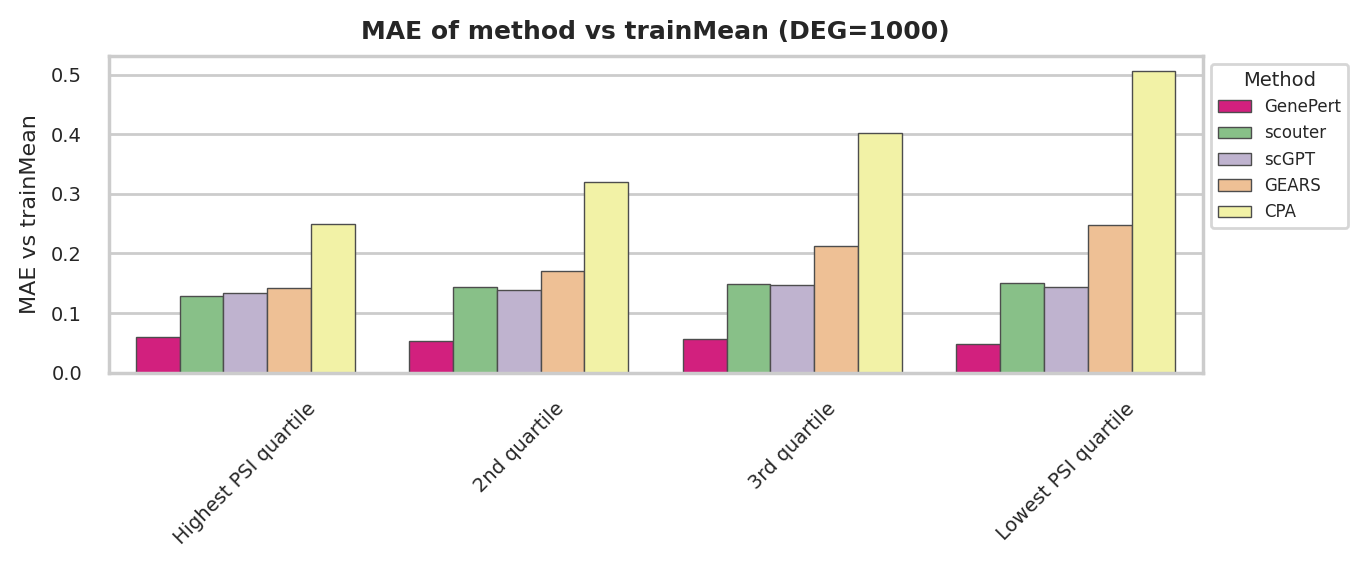

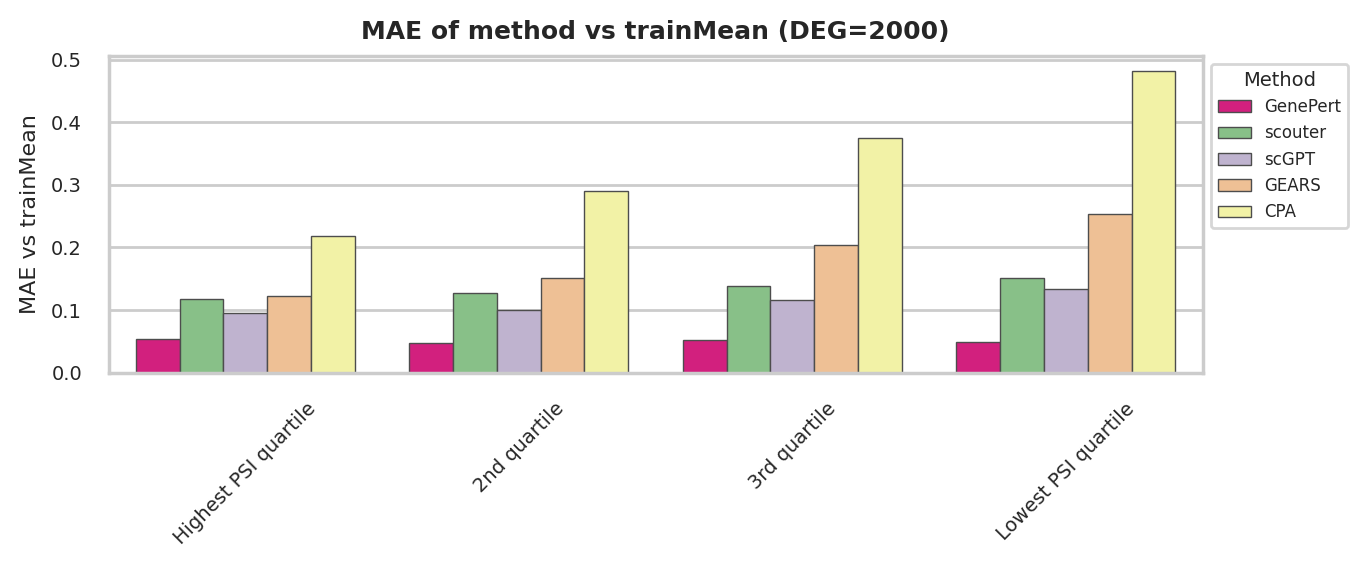

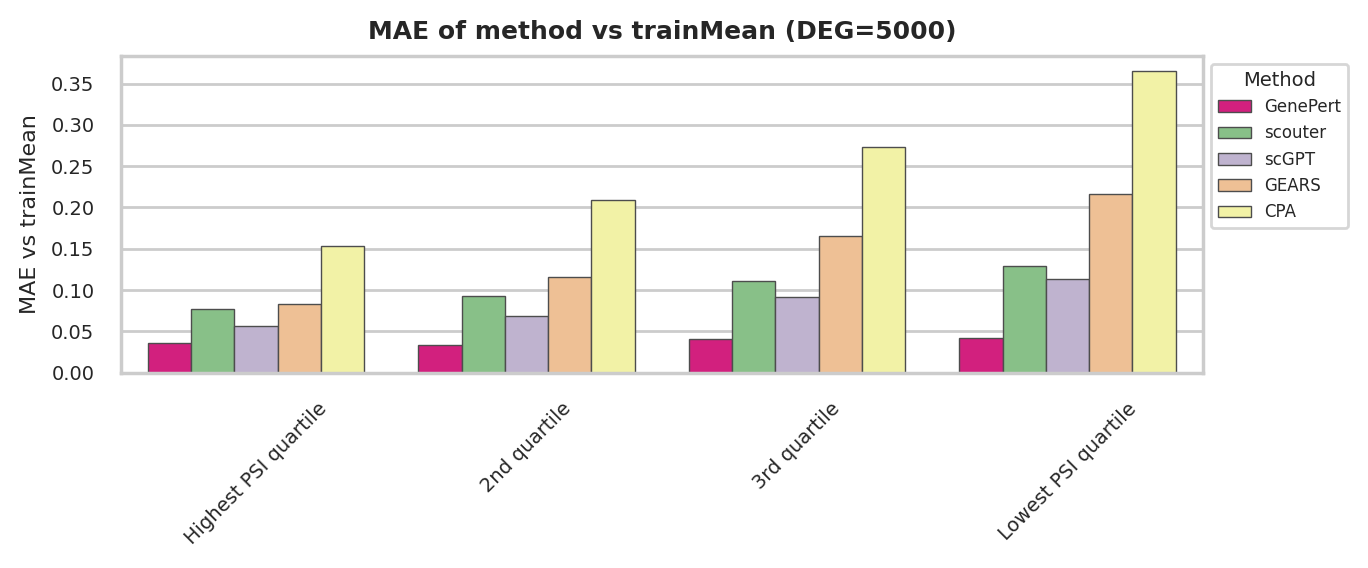

In [24]:
from scipy.stats import spearmanr
import itertools

quarter_names = ['Highest PSI quartile', '2nd quartile', '3rd quartile', 'Lowest PSI quartile']
quarter_lists = [top_quarter, second_quarter, third_quarter, bottom_quarter]
other_methods = [m for m in METHOD_ORDER if m != 'trainMean']

diff_records = []

for deg in [1000, 2000, 5000]:
    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'spearman_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

        for m in other_methods:
            if m in pivot.columns and 'trainMean' in pivot.columns:
                valid = pivot[['trainMean', m]].dropna()
                if len(valid) >= 1:
                    mae = np.mean(np.abs(valid[m].values - valid['trainMean'].values))
                else:
                    mae = np.nan
                diff_records.append({
                    'DEG': deg, 'quarter': qname, 'method': m, 'MAE': mae
                })

diff_df = pd.DataFrame(diff_records)

for deg in [1000, 2000, 5000]:
    df_deg = diff_df[diff_df.DEG == deg]

    fig, ax = plt.subplots(figsize=(7, 3), dpi=200)
    sns.set_theme(style='whitegrid')

    sns.barplot(data=df_deg, x='quarter', y='MAE', hue='method',
                hue_order=other_methods,
                palette={m: PALETTE[m] for m in other_methods},
                edgecolor='0.3', linewidth=0.5, ax=ax,
                order=quarter_names)
    ax.set_xlabel('')
    ax.set_ylabel('MAE vs trainMean', fontsize=8)
    ax.set_title(f'MAE of method vs trainMean (DEG={deg})', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.legend(fontsize=6, title='Method', title_fontsize=7,
              bbox_to_anchor=(1.0, 1.0), loc='upper left')

    plt.tight_layout()
    plt.savefig(f'plots/plot_diff_with_trainMean_DEG{deg}.pdf', bbox_inches='tight', dpi=300)
    plt.show()


Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=5000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ELL      0.5623   0.5786  0.6744  0.4948  0.4585  0.1681     0.4894
POLR2H   0.3529   0.4682  0.6316  0.3978  0.7433  0.4404     0.5057
PAF1     0.6405   0.5377  0.6148  0.3842  0.5483  0.3312     0.5095
MCM3     0.6205   0.6199  0.5709  0.4861  0.5810  0.1860     0.5107
POLR2B   0.7077   0.4806  0.5477  0.3532  0.6371  0.3409     0.5112
CSE1L    0.5420   0.6197  0.5495  0.4995  0.6209  0.2419     0.5122
GTF2E2   0.9281   0.6407  0.5106  0.4089  0.3696  0.2273     0.5142
POLR2A   0.4458   0.4664  0.5401  0.3750  0.6326  0.6543     0.51

In [137]:
from scipy.stats import spearmanr, kendalltau
import itertools
pivot = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=5000, top_n=10, agg_func='mean')
cell_lines = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
mat = pivot[cell_lines].dropna()

# --- Pairwise Spearman correlations ---
rows = []
for a, b in itertools.combinations(cell_lines, 2):
    rho, p = spearmanr(mat[a], mat[b])
    rows.append({'cell_line_1': a, 'cell_line_2': b, 'rho': round(rho, 4), 'p': p})

pairwise = pd.DataFrame(rows)
print("Pairwise Spearman correlations (n={} perturbations)".format(len(mat)))
print(pairwise.to_string(index=False))

# Compact matrix view
rho_mat = pd.DataFrame(np.ones((len(cell_lines), len(cell_lines))),
                        index=cell_lines, columns=cell_lines)
for _, r in pairwise.iterrows():
    rho_mat.loc[r['cell_line_1'], r['cell_line_2']] = r['rho']
    rho_mat.loc[r['cell_line_2'], r['cell_line_1']] = r['rho']
print("\nCorrelation matrix:")
print(rho_mat.round(4).to_string())

# --- Kendall's W ---
# Rank each cell line independently, then compute W
ranks = mat[cell_lines].rank(axis=0)  # rank perturbations within each cell line
n = len(ranks)       # number of perturbations (items)
k = len(cell_lines)  # number of raters (cell lines)
rank_sums = ranks.sum(axis=1)
S = ((rank_sums - rank_sums.mean()) ** 2).sum()
W = 12 * S / (k**2 * (n**3 - n))
print(f"\nKendall's W = {W:.4f}  (k={k} raters, n={n} items)")

Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=5000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ELL      0.5623   0.5786  0.6744  0.4948  0.4585  0.1681     0.4894
POLR2H   0.3529   0.4682  0.6316  0.3978  0.7433  0.4404     0.5057
PAF1     0.6405   0.5377  0.6148  0.3842  0.5483  0.3312     0.5095
MCM3     0.6205   0.6199  0.5709  0.4861  0.5810  0.1860     0.5107
POLR2B   0.7077   0.4806  0.5477  0.3532  0.6371  0.3409     0.5112
CSE1L    0.5420   0.6197  0.5495  0.4995  0.6209  0.2419     0.5122
GTF2E2   0.9281   0.6407  0.5106  0.4089  0.3696  0.2273     0.5142
POLR2A   0.4458   0.4664  0.5401  0.3750  0.6326  0.6543     0.51

Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=5000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ELL      0.5623   0.5786  0.6744  0.4948  0.4585  0.1681     0.4894
POLR2H   0.3529   0.4682  0.6316  0.3978  0.7433  0.4404     0.5057
PAF1     0.6405   0.5377  0.6148  0.3842  0.5483  0.3312     0.5095
MCM3     0.6205   0.6199  0.5709  0.4861  0.5810  0.1860     0.5107
POLR2B   0.7077   0.4806  0.5477  0.3532  0.6371  0.3409     0.5112
CSE1L    0.5420   0.6197  0.5495  0.4995  0.6209  0.2419     0.5122
GTF2E2   0.9281   0.6407  0.5106  0.4089  0.3696  0.2273     0.5142
POLR2A   0.4458   0.4664  0.5401  0.3750  0.6326  0.6543     0.51

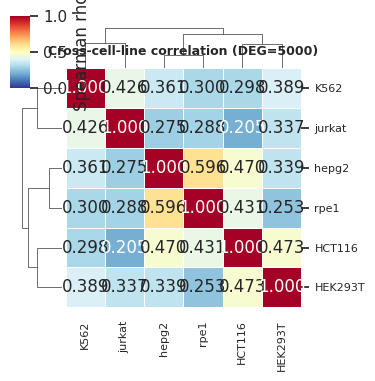

Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=1000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
PAF1     0.4135   0.3065  0.3789  0.1521  0.3047  0.1840     0.2900
CSE1L    0.4641   0.3415  0.2912  0.2665  0.3486  0.1022     0.3024
ERCC2    0.4587   0.3343  0.1852  0.4485  0.2537  0.1553     0.3060
POLR2H   0.1859   0.3327  0.3545  0.2021  0.5741  0.1945     0.3073
ELL      0.6697   0.5538  0.3804  0.2031  0.1928  0.0363     0.3394
SSRP1    0.6286   0.2719  0.1686  0.2799  0.5464  0.2189     0.3524
MCM3     0.5449   0.5074  0.3388  0.1948  0.4822  0.0567     0.3541
RBM25    0.4596   0.5805  0.3649  0.2966  0.3120  0.1466     0.36

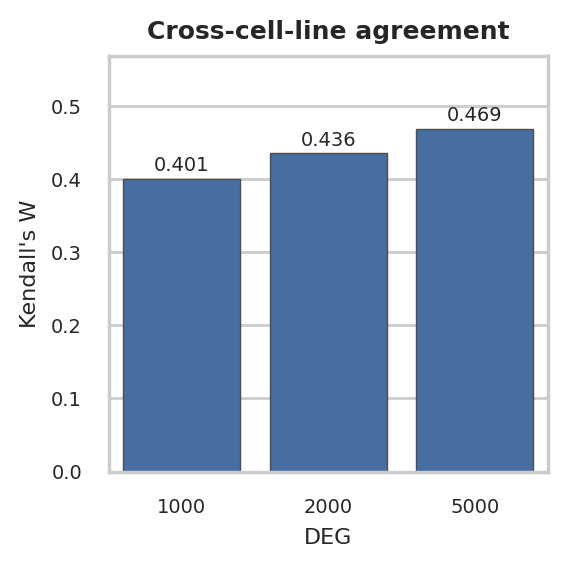

In [138]:
from scipy.stats import spearmanr, kendalltau
from scipy.cluster.hierarchy import linkage, dendrogram
import itertools

cell_lines = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']

# ── DEG=5000: correlation matrix heatmap with clustering ──
pivot = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=5000, top_n=10, agg_func='mean')
mat = pivot[cell_lines].dropna()

rho_mat = pd.DataFrame(np.ones((len(cell_lines), len(cell_lines))),
                        index=cell_lines, columns=cell_lines)
for a, b in itertools.combinations(cell_lines, 2):
    rho, p = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho

# Clustered heatmap
g = sns.clustermap(rho_mat, annot=True, fmt='.3f', cmap='RdYlBu_r',
                   vmin=0, vmax=1, linewidths=0.5,
                   figsize=(4, 4), dendrogram_ratio=0.15,
                   cbar_kws={'label': 'Spearman rho', 'shrink': 0.8},
                   method='average', metric='correlation')
g.ax_heatmap.set_title('Cross-cell-line correlation (DEG=5000)', fontsize=9, fontweight='bold', pad=10)
g.ax_heatmap.tick_params(labelsize=8)
plt.savefig('plots/plot_cellline_corr_clustered.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Kendall's W across DEG levels ──
w_records = []
for deg in [1000, 2000, 5000]:
    pivot_deg = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=deg, top_n=10, agg_func='mean')
    mat_deg = pivot_deg[cell_lines].dropna()
    
    ranks = mat_deg[cell_lines].rank(axis=0)
    n = len(ranks)
    k = len(cell_lines)
    rank_sums = ranks.sum(axis=1)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (k**2 * (n**3 - n))
    w_records.append({'DEG': deg, 'W': W, 'n': n})

w_df = pd.DataFrame(w_records)

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)
sns.set_theme(style='whitegrid')
sns.barplot(data=w_df, x='DEG', y='W', color='#386cb0', edgecolor='0.3', linewidth=0.5, ax=ax)
for i, row in w_df.iterrows():
    ax.text(i, row['W'] + 0.01, f'{row["W"]:.3f}', ha='center', fontsize=7)
ax.set_ylim(0, min(1, w_df['W'].max() + 0.1))
ax.set_xlabel('DEG', fontsize=8)
ax.set_ylabel("Kendall's W", fontsize=8)
ax.set_title("Cross-cell-line agreement", fontsize=9, fontweight='bold')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('plots/plot_kendall_w_by_deg.pdf', bbox_inches='tight', dpi=300)
plt.show()


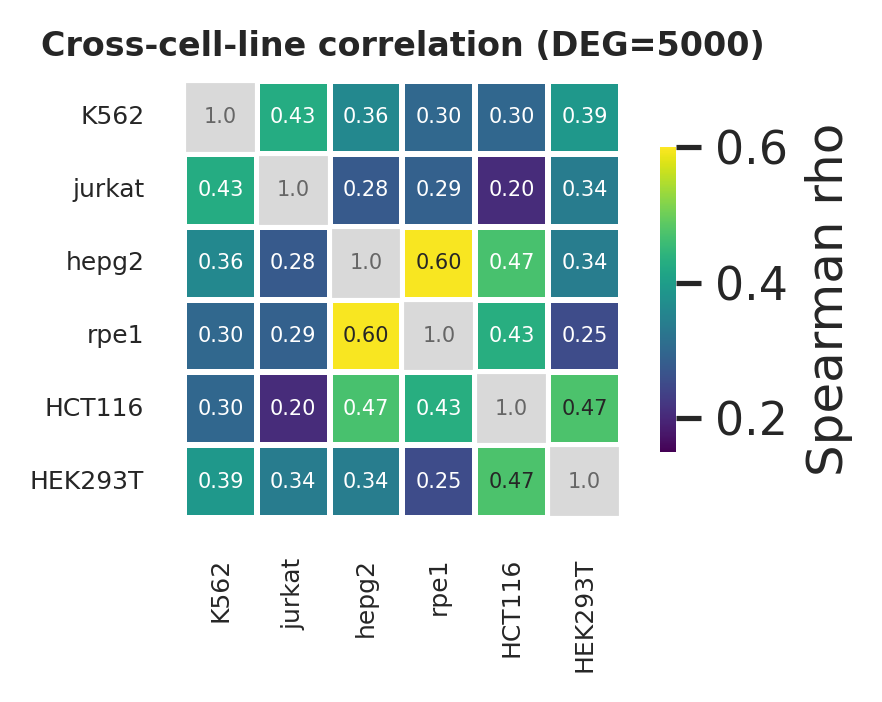

In [143]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Build correlation matrix
rho_mat = pd.DataFrame(np.ones((len(cell_lines), len(cell_lines))),
                        index=cell_lines, columns=cell_lines)
for a, b in itertools.combinations(cell_lines, 2):
    rho, p = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho

# Mask the diagonal
mask = np.eye(len(cell_lines), dtype=bool)

# Cluster order
dist = 1 - rho_mat.values
np.fill_diagonal(dist, 0)
link = linkage(squareform(dist), method='average')
order = leaves_list(link)
rho_ordered = rho_mat.iloc[order, order]
mask_ordered = mask[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)
sns.heatmap(rho_ordered, annot=True, fmt='.2f', cmap='viridis', ax=ax,
            mask=mask_ordered, vmin=0.15, vmax=0.6,
            linewidths=1, linecolor='white', square=True,
            annot_kws={'fontsize': 5},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman rho'})

# Fill diagonal with grey
for i in range(len(cell_lines)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='0.85', lw=1, ec='white'))
    ax.text(i + 0.5, i + 0.5, '1.0', ha='center', va='center', fontsize=5, color='0.4')

ax.set_title('Cross-cell-line correlation (DEG=5000)', fontsize=8, fontweight='bold')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('plots/plot_cellline_corr_clustered.pdf', bbox_inches='tight', dpi=300)
plt.show()
